# 05d — Model Training: Fine-Tuned Wav2Vec2

| Field | Detail |
|---|---|
| **Notebook** | `05d_model_wav2vec2.ipynb` |
| **Pipeline stage** | H1 — Voice Emotion Recognition - 5 of 7 (Model Training, candidate 4 of 4 — the last one) |
| **Owner(s)** | *Thrithwaka Preethi Shakya* |
| **Created** | *28/08/2026* |
| **Last updated** | *28/08/2026* |
| **Upstream dependency** | `04b_feature_extraction_raw_audio.ipynb` (Wav2Vec2-processed waveforms), `04a_feature_extraction_handcrafted.ipynb` (reused class weights) |
| **Downstream dependency** | `06_model_selection.ipynb` |
| **Runs on** | Local machine, or **Google Colab** with the project folder mounted via Google Drive (see Section 0). GPU strongly recommended — this is the largest of the four candidate models. |
| **Research proposal reference** | Section 5.1 (Wav2Vec2 — comparison architecture) |

## Purpose

This is the fourth and final H1 candidate: fine-tuning `facebook/wav2vec2-base`, a transformer model pretrained via self-supervised learning on 960 hours of unlabeled English speech, for our 6-class emotion classification task. Unlike the other three candidates, this model does not learn acoustic representations from scratch on our ~3,250 training examples — it starts from representations already learned from a dataset roughly 1,000x larger, and only adapts them to emotion classification. This is the single biggest architectural difference among the four H1 candidates, and directly tests whether that pretraining advantage translates into better emotion recognition on our specific datasets.

### Two fine-tuning decisions, made explicit

- **The feature encoder is frozen.** Wav2Vec2's first stage is a stack of convolutional layers that convert raw audio into a sequence of local acoustic representations — this is the part of the model that benefited most from the scale of self-supervised pretraining, and is standard practice to freeze (via Hugging Face's own `freeze_feature_encoder()` method) when fine-tuning on a dataset as small as ours, to avoid overwriting those representations with noisy gradients from a few thousand examples. The transformer layers above it remain trainable.
- **Class-weighted loss is computed manually, not via the library default.** `Wav2Vec2ForSequenceClassification`'s built-in loss (when `labels=` is passed directly) is an unweighted cross-entropy — it has no way to know about the class weights computed in `04a`. This notebook instead retrieves only the model's raw logits and applies our own weighted `CrossEntropyLoss` externally, exactly as `05a`\u2013`05c` do, so all four H1 candidates are trained with identical class-weighting treatment.

## Objectives

1. Load and validate the Wav2Vec2-processed waveforms from `04b`, and confirm the official Hugging Face feature extractor (not the offline fallback) was used to produce them.
2. Load `facebook/wav2vec2-base` with a 6-class classification head, freeze its feature encoder, and confirm the resulting trainable parameter count.
3. Fine-tune with class-weighted loss, a conservative learning rate appropriate for fine-tuning (not training from scratch), and early stopping.
4. Evaluate on the held-out test split using Accuracy, Precision, Recall, and F1-score.
5. Save the fine-tuned model in Hugging Face format (compatible with `src/emotion/voice_emotion.py`'s existing `Wav2Vec2VoiceEmotionClassifier`), plus full run metadata.
6. Append this run's results to the shared cross-model experiment log.
7. Leave a structured handoff note, including the research-artifacts-vs-deployment path distinction for this model.

## 0. Environment Setup

### 0.1 Google Colab / Google Drive Setup

Same auto-detecting pattern as `05a`\u2013`05c`. Edit `PROJECT_ROOT` below if your Drive folder path differs from `MyDrive/emotion-ai-companion-research`.

**GPU is strongly recommended for this notebook specifically** (`Runtime` \u2192 `Change runtime type` \u2192 **T4 GPU**) — fine-tuning a 95-million-parameter transformer on CPU would be impractically slow, far more so than any of the other three H1 candidates.

In [1]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_ROOT = Path("/content/drive/MyDrive/emotion-ai-companion-research")

    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"{PROJECT_ROOT} not found. Check that this path matches your Google Drive folder "
            "exactly (case-sensitive), and that the cell above finished mounting successfully."
        )

    os.chdir(PROJECT_ROOT)
    print(f"\u2705 Running on Google Colab. Project root set to: {PROJECT_ROOT}")

else:
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / "config").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent
    print(f"Running locally. Project root resolved to: {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Mounted at /content/drive
✅ Running on Google Colab. Project root set to: /content/drive/MyDrive/emotion-ai-companion-research


In [2]:
import sys
print("Colab Python version:", sys.version)

Colab Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [3]:
!python --version

Python 3.12.13


In [6]:
if IN_COLAB:
    print("Installing project-specific dependencies...")

    !pip install -q \
        pydantic-settings==2.4.0 \
        transformers==4.44.2 \
        tokenizers==0.19.1

    print("Installation completed.")
else:
    print("Running locally — skipping Colab-specific dependency installation.")

Installing project-specific dependencies...
Installation completed.


In [7]:
import json
import time
import logging
import subprocess
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
)

from config.settings import settings  # noqa: E402

sns.set_theme(style="whitegrid")

In [8]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("\u26a0\ufe0f  No GPU detected. Fine-tuning Wav2Vec2 on CPU will be extremely slow. "
          "If on Colab, go to Runtime \u2192 Change runtime type \u2192 T4 GPU before continuing.")

Using device: cuda


In [9]:
LOG_DIR = PROJECT_ROOT / "reports" / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = LOG_DIR / "05d_model_wav2vec2.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("model_wav2vec2")
logger.info("Environment: %s", "Google Colab" if IN_COLAB else "local")

## 1. Load & Validate Upstream Outputs

Confirms the official Hugging Face `Wav2Vec2FeatureExtractor` — not `04b`'s offline fallback — was used to produce the input this notebook will fine-tune on. Fine-tuning on incorrectly-normalized input would not fail loudly; it would just quietly underperform in a way that's hard to diagnose after the fact, which is exactly why this check happens before any training starts.

In [10]:
raw_audio_metadata_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_raw_audio_features_metadata.json"
raw_audio_npz_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_raw_audio_features.npz"
handcrafted_metadata_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_handcrafted_features_metadata.json"

for path in (raw_audio_metadata_path, raw_audio_npz_path, handcrafted_metadata_path):
    if not path.exists():
        raise FileNotFoundError(f"{path} not found. Run 04a and 04b to completion first.")

with open(raw_audio_metadata_path) as f:
    raw_audio_metadata = json.load(f)
with open(handcrafted_metadata_path) as f:
    handcrafted_metadata = json.load(f)

assert raw_audio_metadata["total_files_failed"] == 0, "04b reported extraction failures — resolve before training."

WAV2VEC2_CHECKPOINT = raw_audio_metadata["wav2vec2_branch"]["checkpoint"]
used_official_extractor = raw_audio_metadata["wav2vec2_branch"]["used_official_hf_extractor"]

if not used_official_extractor:
    print(
        "\n\u26a0\ufe0f  \u26a0\ufe0f  \u26a0\ufe0f  WARNING \u26a0\ufe0f  \u26a0\ufe0f  \u26a0\ufe0f\n"
        "04b_feature_extraction_raw_audio.ipynb used its OFFLINE FALLBACK normalization, not the \n"
        "official Wav2Vec2FeatureExtractor, when it produced this notebook's input data.\n"
        "Fine-tuning on this data risks a subtle mismatch with what the pretrained model expects.\n"
        "STRONGLY RECOMMENDED: re-run 04b with network access before trusting this notebook's results.\n"
    )
    logger.warning("Proceeding with Wav2Vec2 fine-tuning despite the offline-fallback flag being set.")
else:
    print(f"\u2705 Confirmed: 04b used the official Wav2Vec2FeatureExtractor for checkpoint '{WAV2VEC2_CHECKPOINT}'.")

label_to_idx = {k: int(v) for k, v in raw_audio_metadata["label_to_idx"].items()}
idx_to_label = {int(k): v for k, v in raw_audio_metadata["idx_to_label"].items()}
assert label_to_idx == {k: int(v) for k, v in handcrafted_metadata["label_to_idx"].items()}, (
    "Label encoding mismatch between 04a and 04b metadata — do not proceed until resolved."
)
NUM_CLASSES = len(label_to_idx)
print(f"{NUM_CLASSES} classes: {list(label_to_idx.keys())}")

✅ Confirmed: 04b used the official Wav2Vec2FeatureExtractor for checkpoint 'facebook/wav2vec2-base'.
6 classes: ['happy', 'sad', 'angry', 'fear', 'neutral', 'surprise']


In [11]:
data = np.load(raw_audio_npz_path, allow_pickle=True)
X_wav2vec2, y, split = data["X_wav2vec2"], data["y"], data["split"]

print(f"X_wav2vec2 shape: {X_wav2vec2.shape}")
print(f"Split sizes: {pd.Series(split).value_counts().to_dict()}")

X_wav2vec2 shape: (4068, 40000)
Split sizes: {'train': 3254, 'val': 407, 'test': 407}


## 2. Configuration

Fine-tuning hyperparameters are deliberately different from `05a`\u2013`05c`'s from-scratch training: a much lower learning rate (`3e-5` vs. `1e-3`) and higher weight decay (`0.01` vs. `1e-4`) are standard practice when adapting an already-pretrained transformer, to avoid destructively large updates to weights that already encode useful information. A smaller batch size (`8`) is used to stay within typical free-tier GPU memory limits, since this model is far larger than the other three candidates.

In [12]:
BATCH_SIZE = 8               # smaller than 05a-05c's batch sizes — Wav2Vec2 is far larger (~95M params)
MAX_EPOCHS = 30              # fine-tuning typically converges faster than training from scratch
LEARNING_RATE = 3e-5         # a conservative fine-tuning LR, ~30x smaller than 05a-05c's 1e-3
WEIGHT_DECAY = 0.01          # standard for transformer fine-tuning, higher than 05a-05c's 1e-4
LR_SCHEDULER_PATIENCE = 2
LR_SCHEDULER_FACTOR = 0.5
EARLY_STOPPING_PATIENCE = 3  # lower than 05a-05c's 5, since fine-tuning tends to overfit faster

MODEL_DIR = PROJECT_ROOT / "models" / "h1"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
WAV2VEC2_MODEL_DIR = MODEL_DIR / "wav2vec2_finetuned"  # Hugging Face format needs a directory, not a single file
MODEL_METADATA_PATH = MODEL_DIR / "wav2vec2_metadata.json"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "h1_models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_LOG_PATH = PROJECT_ROOT / "reports" / "experiment_log.csv"

logger.info(
    "Config: batch_size=%d, max_epochs=%d, lr=%.0e, weight_decay=%.3f",
    BATCH_SIZE, MAX_EPOCHS, LEARNING_RATE, WEIGHT_DECAY,
)

## 3. Dataset and DataLoaders

In [13]:
class WaveformDataset(Dataset):
    """Wav2Vec2ForSequenceClassification expects (batch, sequence_length) — no channel dimension."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_mask, val_mask, test_mask = split == "train", split == "val", split == "test"

train_dataset = WaveformDataset(X_wav2vec2[train_mask], y[train_mask])
val_dataset = WaveformDataset(X_wav2vec2[val_mask], y[val_mask])
test_dataset = WaveformDataset(X_wav2vec2[test_mask], y[test_mask])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(RANDOM_SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 3254 | Val: 407 | Test: 407


In [14]:
class_weights_by_label = handcrafted_metadata["class_weights"]
class_weights_tensor = torch.tensor(
    [class_weights_by_label[idx_to_label[i]] for i in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(DEVICE)

print("Class weights (reused from 04a) in label-index order:")
for i in range(NUM_CLASSES):
    print(f"  {i} ({idx_to_label[i]}): {class_weights_tensor[i].item():.4f}")

Class weights (reused from 04a) in label-index order:
  0 (happy): 1.0409
  1 (sad): 1.0390
  2 (angry): 1.0390
  3 (fear): 1.0390
  4 (neutral): 0.8395
  5 (surprise): 1.0409


## 4. Load Pretrained Model and Freeze the Feature Encoder

Downloads `facebook/wav2vec2-base` from the Hugging Face Hub (network access required, one-time — the checkpoint is cached locally afterward) and attaches a fresh, randomly-initialized 6-class classification head. The feature encoder is then frozen, and the trainable parameter count is printed so it's visible exactly how much of the 95-million-parameter model is actually being updated during fine-tuning.

In [15]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    WAV2VEC2_CHECKPOINT, num_labels=NUM_CLASSES
).to(DEVICE)

model.freeze_feature_encoder()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params / total_params:.1%} of total)")
logger.info("Loaded %s. Trainable params: %d / %d", WAV2VEC2_CHECKPOINT, trainable_params, total_params)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:364: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     94,570,118
Trainable parameters: 90,369,670 (95.6% of total)


## 5. Training Loop

Same structural discipline as `05a`\u2013`05c` — class-weighted loss computed externally (not the model's built-in unweighted loss), `ReduceLROnPlateau`, early stopping on validation loss, best checkpoint saved by validation loss.

In [16]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE
)


def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            logits = model(input_values=X_batch).logits  # raw logits only — our own weighted loss below
            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

In [17]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
epochs_without_improvement = 0
best_epoch = 0

training_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    logger.info(
        "Epoch %3d | train_loss=%.4f train_acc=%.4f | val_loss=%.4f val_acc=%.4f | lr=%.2e",
        epoch, train_loss, train_acc, val_loss, val_acc, current_lr,
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0
        model.save_pretrained(WAV2VEC2_MODEL_DIR)  # HF checkpoints are saved as a directory, overwritten each improvement
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        logger.info("Early stopping triggered at epoch %d (best epoch: %d).", epoch, best_epoch)
        print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, best val_loss: {best_val_loss:.4f})")
        break

training_duration_seconds = time.time() - training_start
print(f"\nTraining complete in {training_duration_seconds:.1f}s. Best epoch: {best_epoch} (val_loss={best_val_loss:.4f}).")

Early stopping at epoch 9 (best epoch: 6, best val_loss: 0.1645)

Training complete in 1335.3s. Best epoch: 6 (val_loss=0.1645).


## 6. Save the Feature Extractor Alongside the Model

`src/emotion/voice_emotion.py`'s existing `Wav2Vec2VoiceEmotionClassifier` loads both a model *and* a feature extractor from the same directory via `from_pretrained()`. Saving the extractor here — not just the fine-tuned model — means that module will work correctly out of the box if this model is later promoted to deployment, with no additional glue code needed.

In [18]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(WAV2VEC2_CHECKPOINT)
feature_extractor.save_pretrained(WAV2VEC2_MODEL_DIR)
logger.info("Saved feature extractor alongside the fine-tuned model at %s", WAV2VEC2_MODEL_DIR)
print(f"Feature extractor saved alongside model at: {WAV2VEC2_MODEL_DIR}")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

Feature extractor saved alongside model at: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/wav2vec2_finetuned


## 7. Training Curves

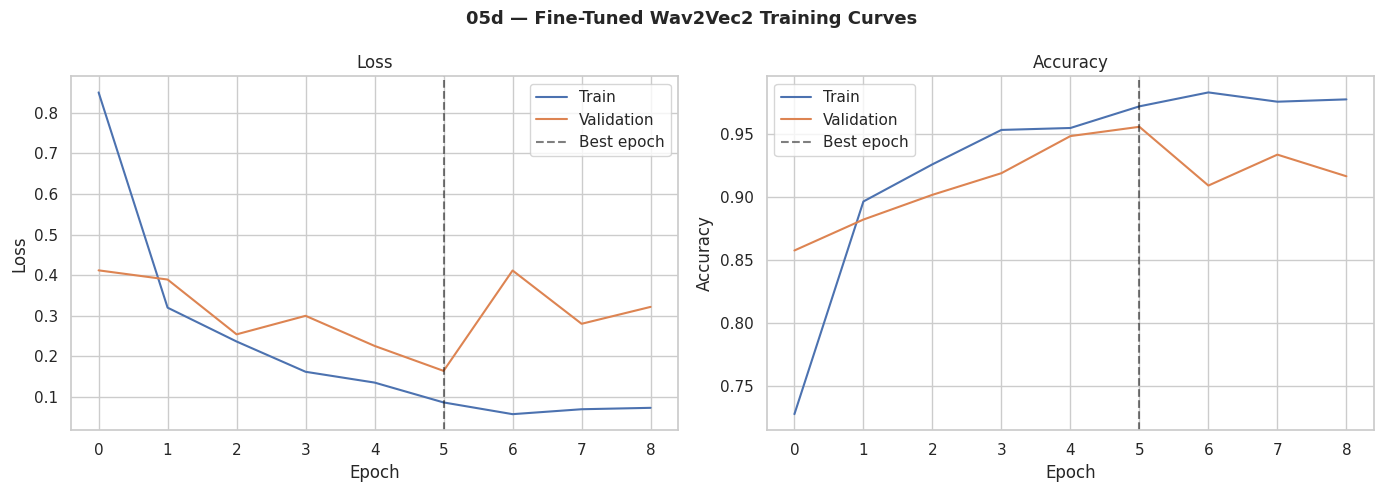

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Validation")
axes[0].axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.5, label="Best epoch")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"], label="Validation")
axes[1].axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.5, label="Best epoch")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

fig.suptitle("05d — Fine-Tuned Wav2Vec2 Training Curves", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05d_training_curves.png")
plt.show()

## 8. Test Set Evaluation

Reloads the best checkpoint from disk via `from_pretrained()` (Hugging Face's own loading path, not a raw `state_dict` load) — this is also an implicit end-to-end test that the model was saved correctly and can be loaded exactly as `06_model_selection.ipynb` and any future deployment code will load it.

In [20]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(WAV2VEC2_MODEL_DIR).to(DEVICE)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = model(input_values=X_batch).logits
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

test_accuracy = accuracy_score(all_labels, all_preds)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print(f"Test Accuracy:            {test_accuracy:.4f}")
print(f"Test Precision (macro):   {precision_macro:.4f}")
print(f"Test Recall (macro):      {recall_macro:.4f}")
print(f"Test F1 (macro):          {f1_macro:.4f}")
print(f"Test F1 (weighted):       {f1_weighted:.4f}")
print("\nPer-class report:\n")
print(classification_report(
    all_labels, all_preds, target_names=[idx_to_label[i] for i in range(NUM_CLASSES)], zero_division=0
))

Test Accuracy:            0.9484
Test Precision (macro):   0.9530
Test Recall (macro):      0.9469
Test F1 (macro):          0.9492
Test F1 (weighted):       0.9486

Per-class report:

              precision    recall  f1-score   support

       happy       0.94      0.91      0.92        66
         sad       0.98      0.91      0.94        65
       angry       0.94      0.95      0.95        65
        fear       1.00      0.97      0.98        65
     neutral       0.89      0.99      0.94        81
    surprise       0.97      0.95      0.96        65

    accuracy                           0.95       407
   macro avg       0.95      0.95      0.95       407
weighted avg       0.95      0.95      0.95       407



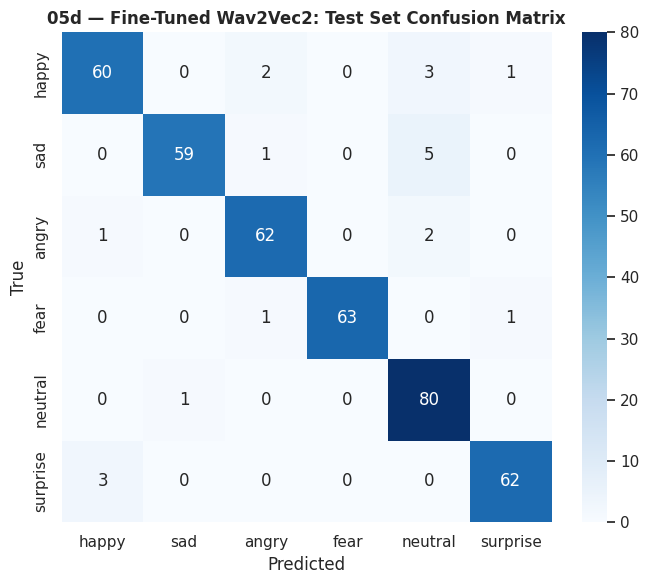

In [21]:
cm = confusion_matrix(all_labels, all_preds)
labels_ordered = [idx_to_label[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_ordered, yticklabels=labels_ordered, ax=ax)
ax.set_title("05d — Fine-Tuned Wav2Vec2: Test Set Confusion Matrix", fontsize=12, weight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05d_confusion_matrix.png")
plt.show()

## 9. Save Model Metadata

In [22]:
def get_git_commit_hash() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return "unknown"


model_metadata = {
    "model_name": "wav2vec2",
    "architecture": f"Fine-tuned {WAV2VEC2_CHECKPOINT} (feature encoder frozen, transformer + classification head trainable)",
    "base_checkpoint": WAV2VEC2_CHECKPOINT,
    "used_official_hf_extractor_upstream": used_official_extractor,
    "num_classes": NUM_CLASSES,
    "label_to_idx": label_to_idx,
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
        "feature_encoder_frozen": True,
    },
    "training": {
        "best_epoch": best_epoch,
        "epochs_run": len(history["train_loss"]),
        "best_val_loss": float(best_val_loss),
        "training_duration_seconds": round(training_duration_seconds, 1),
        "device": str(DEVICE),
        "environment": "Google Colab" if IN_COLAB else "local",
        "total_parameters": int(total_params),
        "trainable_parameters": int(trainable_params),
    },
    "test_metrics": {
        "accuracy": float(test_accuracy),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    },
    "git_commit": get_git_commit_hash(),
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "model_dir": str(WAV2VEC2_MODEL_DIR.relative_to(PROJECT_ROOT)),
}

with open(MODEL_METADATA_PATH, "w") as f:
    json.dump(model_metadata, f, indent=2)

logger.info("Saved model metadata to %s", MODEL_METADATA_PATH)
print(f"Saved: {WAV2VEC2_MODEL_DIR}/ (Hugging Face format: model + feature extractor)")
print(f"Saved: {MODEL_METADATA_PATH}")

Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/wav2vec2_finetuned/ (Hugging Face format: model + feature extractor)
Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/wav2vec2_metadata.json


## 10. Append to Shared Experiment Log

In [23]:
experiment_row = {
    "notebook": "05d_model_wav2vec2",
    "model_name": "wav2vec2",
    "timestamp_utc": model_metadata["trained_at_utc"],
    "git_commit": model_metadata["git_commit"],
    "environment": model_metadata["training"]["environment"],
    "test_accuracy": test_accuracy,
    "test_precision_macro": precision_macro,
    "test_recall_macro": recall_macro,
    "test_f1_macro": f1_macro,
    "test_f1_weighted": f1_weighted,
    "best_epoch": best_epoch,
    "epochs_run": len(history["train_loss"]),
    "total_parameters": total_params,
    "training_duration_seconds": round(training_duration_seconds, 1),
    "model_metadata_path": str(MODEL_METADATA_PATH.relative_to(PROJECT_ROOT)),
}

experiment_log_df = (
    pd.read_csv(EXPERIMENT_LOG_PATH) if EXPERIMENT_LOG_PATH.exists() else pd.DataFrame()
)
experiment_log_df = pd.concat([experiment_log_df, pd.DataFrame([experiment_row])], ignore_index=True)
experiment_log_df.to_csv(EXPERIMENT_LOG_PATH, index=False)

logger.info("Appended results to shared experiment log: %s", EXPERIMENT_LOG_PATH)
print(f"Appended to: {EXPERIMENT_LOG_PATH}")
experiment_log_df.tail(5)

Appended to: /content/drive/MyDrive/emotion-ai-companion-research/reports/experiment_log.csv


,notebook,model_name,timestamp_utc,git_commit,environment,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,best_epoch,epochs_run,total_parameters,training_duration_seconds,model_metadata_path,note
1,05b_model_cnn_lstm,cnn_lstm,2026-08-29T08:31:10.368142+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.889435,0.891326,0.886991,0.888323,0.889131,18.0,23.0,331078.0,14.1,models/h1/cnn_lstm_metadata.json,NaN
2,05c_model_ensemble,ensemble_cnn_branch,2026-08-29T11:28:48.348098+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.877150,0.875174,0.873742,0.873887,0.876187,4.0,9.0,NaN,28.0,models/h1/ensemble_metadata.json,"Individual branch — diagnostic only, not the o..."
3,05c_model_ensemble,ensemble_cnn_bilstm_branch,2026-08-29T11:28:48.348098+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.894349,0.897715,0.891029,0.892594,0.894756,6.0,11.0,NaN,35.6,models/h1/ensemble_metadata.json,"Individual branch — diagnostic only, not the o..."
4,05c_model_ensemble,ensemble,2026-08-29T11:28:48.348098+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.889435,0.889915,0.886952,0.887376,0.889292,NaN,NaN,NaN,63.7,models/h1/ensemble_metadata.json,OFFICIAL H1 candidate 3 of 4 — averaged predic...
5,05d_model_wav2vec2,wav2vec2,2026-08-29T15:09:16.638989+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.948403,0.952978,0.946893,0.949155,0.948561,6.0,9.0,94570118.0,1335.3,models/h1/wav2vec2_metadata.json,NaN


## 11. Final Sanity Check — Reload and Verify

With all four H1 candidates now trained, this cell also prints a preview of the complete comparison table — the actual input `06_model_selection.ipynb` will use.

In [24]:
reload_model = Wav2Vec2ForSequenceClassification.from_pretrained(WAV2VEC2_MODEL_DIR).to(DEVICE)
reload_model.eval()

sample_X, sample_y = next(iter(test_loader))
with torch.no_grad():
    reload_logits = reload_model(input_values=sample_X.to(DEVICE)).logits
    reload_preds = reload_logits.argmax(dim=1).cpu()

assert reload_logits.shape == (sample_X.shape[0], NUM_CLASSES), "Unexpected output shape from reloaded model!"
print("\u2705 Reloaded model (via from_pretrained) produces correctly-shaped output.")
print(f"Sample predictions: {[idx_to_label[p.item()] for p in reload_preds[:5]]}")
print(f"Sample true labels: {[idx_to_label[l.item()] for l in sample_y[:5]]}")

✅ Reloaded model (via from_pretrained) produces correctly-shaped output.
Sample predictions: ['angry', 'sad', 'surprise', 'neutral', 'surprise']
Sample true labels: ['angry', 'sad', 'surprise', 'neutral', 'surprise']


In [25]:
print("Preview of the full H1 model-selection comparison (all candidates trained so far):\n")
preview_cols = ["model_name", "test_accuracy", "test_f1_macro", "test_f1_weighted", "environment"]
available_cols = [c for c in preview_cols if c in experiment_log_df.columns]
display(experiment_log_df[available_cols].sort_values("test_f1_macro", ascending=False))

Preview of the full H1 model-selection comparison (all candidates trained so far):



,model_name,test_accuracy,test_f1_macro,test_f1_weighted,environment
5,wav2vec2,0.948403,0.949155,0.948561,Google Colab
3,ensemble_cnn_bilstm_branch,0.894349,0.892594,0.894756,Google Colab
1,cnn_lstm,0.889435,0.888323,0.889131,Google Colab
4,ensemble,0.889435,0.887376,0.889292,Google Colab
2,ensemble_cnn_branch,0.877150,0.873887,0.876187,Google Colab
0,cnn_raw,0.803440,0.801215,0.804571,Google Colab


---

## Summary Note — Handoff
### What was done in this notebook

1. Detected the runtime environment and confirmed `04b` used the official Wav2Vec2 feature extractor (not its offline fallback).
2. Loaded `facebook/wav2vec2-base`, attached a 6-class classification head, and froze the feature encoder — printing the resulting trainable parameter fraction.
3. Fine-tuned with a conservative learning rate, our own class-weighted loss (not the library default), `ReduceLROnPlateau`, and early stopping.
4. Evaluated the best checkpoint (reloaded via `from_pretrained`, not a raw state dict) on the test split: Accuracy, Precision, Recall, F1, full classification report, confusion matrix.
5. Saved the fine-tuned model **and** its feature extractor together, in Hugging Face format, matching what `src/emotion/voice_emotion.py`'s existing `Wav2Vec2VoiceEmotionClassifier` expects.
6. Appended this run's results to `reports/experiment_log.csv` — completing all four H1 candidates.
7. Previewed the full four-candidate comparison table.

### Outputs produced by this notebook (and where to find them)

| Output | Location | Used by |
|---|---|---|
| Fine-tuned model + feature extractor (Hugging Face format) | `models/h1/wav2vec2_finetuned/` | `06_model_selection.ipynb`; `src/emotion/voice_emotion.py` if this model is promoted to deployment |
| Model metadata | `models/h1/wav2vec2_metadata.json` | `06_model_selection.ipynb`; thesis results section |
| Training curves / confusion matrix figures | `reports/figures/h1_models/05d_*.png` | Thesis results/appendix |
| Shared experiment log (one row appended) | `reports/experiment_log.csv` | `06_model_selection.ipynb` — now has all four candidates |
| Run log | `reports/logs/05d_model_wav2vec2.log` | Debugging |

### An important path distinction for this specific model

`config/settings.py` defines `wav2vec2_model_path = "models/voice_emotion/wav2vec2_finetuned"` — the path the **live Streamlit app** expects. This notebook deliberately saves to `models/h1/wav2vec2_finetuned/` instead, alongside the other three research-phase candidates, since this model has not yet been confirmed as the H1 winner. **If `06_model_selection.ipynb` selects this model**, copy (or move) `models/h1/wav2vec2_finetuned/` to `models/voice_emotion/wav2vec2_finetuned/` as a deliberate, explicit promotion step — don't save directly to the deployment path prematurely.

### What needs to be done next

With all four H1 candidates now trained (`05a` raw CNN, `05b` CNN-LSTM, `05c` ensemble, `05d` Wav2Vec2), proceed to **`06_model_selection.ipynb`**, which should:

- Load `reports/experiment_log.csv` and compare all candidates (filtering `05c`'s log entries to `model_name == "ensemble"` for that notebook's official entry).
- Select the single best-performing voice model by the metrics defined in the research proposal (Section 5.5).
- Optionally run a paired significance test between the top two candidates if the difference is close, before declaring a winner.
- Hand the winning model off to `07_h1_final_evaluation.ipynb` for the actual H1 hypothesis test (winning voice model vs. DistilRoBERTa, using `04c`'s transcripts).

**Before running `06_model_selection.ipynb`, confirm:**
- All four rows (plus `05c`'s two diagnostic branch rows) appear in `reports/experiment_log.csv`.
- `models/h1/wav2vec2_finetuned/` contains both model and feature-extractor files, and `wav2vec2_metadata.json` exists.
- Section 11's reload sanity check printed \u2705.
- If `used_official_hf_extractor_upstream` is `false` in this notebook's metadata, treat this candidate's results with appropriate caution and consider re-running `04b` and this notebook with network access before finalizing.

### Resources needed for the next step

| Resource | Needed for | Notes |
|---|---|---|
| `reports/experiment_log.csv` | Full four-candidate comparison | This is now complete after this notebook |
| `models/h1/*` (all four candidates' artifacts) | Loading any candidate for further analysis | Each candidate has its own subdirectory or file set — see each notebook's own metadata for exact paths |

### Known issues / things to watch for

- *None*

### Run metadata

- **Run by:** *Thrithwaka Preethi Shakaya*
- **Date:** *28/08/2026*
- **Environment:** *Colab*
- **Official HF extractor confirmed upstream:** *Yes*
- **Trainable / total parameters:** *Total parameters:     94,570,118
Trainable parameters: 90,369,670 (95.6% of total)*
- **Test accuracy / F1 (macro):** *0.9492*